## **Import libraries**

In [ ]:
import os
import random

SEED = 8
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import numpy as np
import pandas as pd

from natsort import natsorted

import torch
import torch.nn as nn
from transformers import set_seed as transformers_set_seed

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

def seed_everything(seed: int = SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    transformers_set_seed(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    torch.use_deterministic_algorithms(True)

seed_everything(SEED)

from SARVI.config import (
    paths
)
from SARVI.models.schemas import (
    PipelineContext,
    DOCXToJSONSConfig,
    LLMConfig
)

from SARVI.data_io.reader import (
    textwrap,
    read_txt_list, read_ann_list,
    read_json_single,
    read_excel_single
)

from SARVI.services.common.llm_loader import (
    load_llm
)
from SARVI.services.common.tree_funcs import (
    load_tree_hierarchical_module
)
from SARVI.services.common.llm_funcs import (
    prompts as prompts_total
)
from SARVI.services.common.ner_funcs import(
    tokenizer_ner, model_ner
)
from SARVI.services.common.re_funcs import (
    initialize_re_model,
    undersample_re_negatives, remap_re_relation_labels
)
from SARVI.services.sync_funcs.re_funcs import(
    prepare_data as prepare_data_SYNC,
    construct_loader_re as construct_loader_re_SYNC,
    run_re_classifier as run_re_classifier_SYNC
)
from SARVI.services.async_funcs.llm_funcs import (
    asyncio
)

from SARVI.models.losses import MoMLoss

from SARVI.data_io.writing import (
    write_torch_checkpoint, write_json_extra_docs, write_parquet
)

Some weights of XLMRobertaModel were not initialized from the model checkpoint at IIC/RigoBERTa-Clinical and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of XLMRobertaModel were not initialized from the model checkpoint at IIC/RigoBERTa-Clinical and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[2026-06-01 13:15:58] INFO SentenceTransformer.py:219: Use pytorch device_name: cuda:0
[2026-06-01 13:15:58] INFO SentenceTransformer.py:227: Load pretrained SentenceTransformer: all-MiniLM-L6-v2


## **Initialize variables**

In [ ]:
def initialize_variables(ctx: PipelineContext):
    print("0. Initializing variables\n")
    # create_intermediate_folder_name(ctx)

    #################################################################################################################

    if ctx.cie_10_version == "2018":
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2018.xlsx", sheet_name="finales", header=0)
        df_reference = df_reference[['codigo', 'descripcion']].reset_index(drop=True).rename(columns={'codigo': 'Código', 'descripcion': 'Descripción'})
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    elif ctx.cie_10_version == "2024":
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2024.xlsx", sheet_name="ES2024 Completa + Marcadores", header=0)
        df_reference = df_reference[["Código", "Descripción"]].reset_index(drop=True)
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    else:
        df_reference = read_excel_single(ctx, "Diagnosticos_ES2026.xlsx", sheet_name="ES2026 Completa + Marcadores", header=0)
        df_reference = df_reference[["Código", "Descripción"]].reset_index(drop=True)
        df_reference["Código"] = (df_reference["Código"].astype(str).str.strip().str.replace("\xa0", "", regex=False))
        df_reference = df_reference[df_reference["Código"].str.match(r"^[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?(?:-[A-Za-z]\d[A-Za-z0-9](?:\.[A-Za-z0-9]+)?)?$")]

    #################################################################################################################

    report_list = natsorted(p for p in (ctx.paths.data_input / ctx.folder_and_archive_name).iterdir() if p.is_file())
    
    if ctx.ussage == "generative":
        llm = load_llm(ctx.llm_config)
        prompt = textwrap.dedent(prompts_total["report_to_data"])
        modelo_ner = None
        node_list = None
        modelo_icd10_head = None
        modelo_icd10_prediction = None
        label2id_ICD10 = None
        id2label_ICD10 = None
        id_no_hs_to_id_hs = None
        icd10_thresholds = None
    else:
        llm = None
        prompt = None
        modelo_ner = [None, None]
        node_list = load_tree_hierarchical_module(df_reference)

        root = node_list["root"]
        root.set_indexes()
        label2id_hs = {key.name: value for key, value in root.node_to_id.items()}
        id2label_hs = {value: key for key, value in label2id_hs.items()}
        label2id_no_hs = {id2label_hs[value.item()]: i for i, value in enumerate(root.leaf_indexes)}
        id2label_no_hs = {value: key for key, value in label2id_no_hs.items()}
        label2id_ICD10 = [label2id_hs, label2id_no_hs]
        id2label_ICD10 = [id2label_hs, id2label_no_hs]
        id_no_hs_to_id_hs = {id_no_hs: label2id_hs[label_name] for label_name, id_no_hs in label2id_no_hs.items()}

        # modelo_icd10_head = [initialize_icd10_hs_head_model(ctx, "ICD10_HS_checkpoint.pt", root), initialize_icd10_no_hs_head_model(ctx, "ICD10_NO_HS_checkpoint.pt", label2id_no_hs, root)]
        # modelo_icd10_prediction = [initialize_icd10_hs_prediction_model(ctx, "ICD10_HS_checkpoint.pt", label2id_hs, root), None]
        modelo_icd10_head = None
        modelo_icd10_prediction = None
        icd10_thresholds = read_json_single(ctx.paths.docs_dir / "thresholds_ICD10.json")
    
    semaforo = asyncio.Semaphore(ctx.MAX_CONCURRENCY)

    config = DOCXToJSONSConfig(
        report_list=report_list,
        prompt=prompt,
        llm=llm,
        semaforo=semaforo,
        modelo_ner=modelo_ner,
        node_list=node_list,
        modelo_icd10_head=modelo_icd10_head,
        modelo_icd10_prediction=modelo_icd10_prediction,
        label2id_ICD10=label2id_ICD10,
        id2label_ICD10=id2label_ICD10,
        id_no_hs_to_id_hs=id_no_hs_to_id_hs,
        icd10_thresholds=icd10_thresholds
    )

    return config

In [3]:
llm_config = LLMConfig(
    service="vllm",
    model="openai/gpt-oss-20b",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

ctx = PipelineContext(
    ussage="deterministic",
    folder_and_archive_name="CT-EBM-SP-v3/train",
    llm_config=llm_config,
    paths=paths,
    cie_10_version="2026",
    json_parse=False,
    device = "cuda" if torch.cuda.is_available() else "cpu"
)

config = initialize_variables(ctx)

0. Initializing variables



Hierarchical tree construction: Cleaning data:   0%|          | 0/102426 [00:00<?, ?code/s]

## **Run RE data creation**

In [4]:
"""
data_prepared = [
    [  # file/text 0
        {example for pair T1-T2},
        {example for pair T1-T3},
        ...
    ],
    [  # file/text 1
        {example for pair T4-T5},
        ...
    ],
    ...
]


{
    "input_ids": [...],
    "attention_mask": [...],
    "position_ids": [...],
    "original_position_ids": [...],
    "marker_positions": {
        "<S:DISO>": [3],
        "</S:DISO>": [5],
        "<O:LIVB>": [14],
        "</O:LIVB>": [19],
    },
    "marked_text": "... <S:DISO>diabetes</S:DISO> ... <O:LIVB>ayer</O:LIVB> ...",
    "left_entity": {...},
    "right_entity": {...},
    "file_name": "...",
}
"""

'\ndata_prepared = [\n    [  # file/text 0\n        {example for pair T1-T2},\n        {example for pair T1-T3},\n        ...\n    ],\n    [  # file/text 1\n        {example for pair T4-T5},\n        ...\n    ],\n    ...\n]\n\n\n{\n    "input_ids": [...],\n    "attention_mask": [...],\n    "position_ids": [...],\n    "original_position_ids": [...],\n    "marker_positions": {\n        "<S:DISO>": [3],\n        "</S:DISO>": [5],\n        "<O:LIVB>": [14],\n        "</O:LIVB>": [19],\n    },\n    "marked_text": "... <S:DISO>diabetes</S:DISO> ... <O:LIVB>ayer</O:LIVB> ...",\n    "left_entity": {...},\n    "right_entity": {...},\n    "file_name": "...",\n}\n'

### **Create data**

In [5]:
token_distance_bins = {0: (0, 0), 1: (1, 2), 2: (3, 5), 3: (6, 10), 4: (11, 20), 5: (21, 40), 6: (41, 80), 7: (81, 160), 8: (161, float("inf"))}
negative_difficulty_by_bin = {0: "hard", 1: "hard", 2: "hard", 3: "hard", 4: "medium", 5: "medium", 6: "easy", 7: "easy", 8: "easy"}

print("1.1. Creating NER data // Train data")
dict_data_train = read_txt_list(ctx.paths.data_input / ctx.folder_and_archive_name)
df_data_train = pd.DataFrame(list(dict_data_train.items()), columns=["archivo_origen", "Text"])

dict_ann_train = read_ann_list(ctx.paths.data_input / ctx.folder_and_archive_name)
df_ann_train = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_train.items()])
# df_ann = None

data_prepared_train, all_relation_labels_train, file_names_train, preparation_warnings_train, tokenizer_re = prepare_data_SYNC(data=df_data_train, data_ann=df_ann_train, entity_label_1="DISO", entity_label_2="LIVB", tokenizer=tokenizer_ner, w=2, v=1, 
                                                                                                                               token_distance_bins=token_distance_bins, negative_difficulty_by_bin=negative_difficulty_by_bin, print_warnings=False, return_tokenizer=True)
model_ner.resize_token_embeddings(len(tokenizer_re))

data_prepared_train, all_relation_labels_train = undersample_re_negatives(data_prepared_train, all_relation_labels_train, outside_label="O", 
                                                                                        max_hard_negative_ratio=2, max_medium_negative_ratio=3, max_easy_negative_ratio=1, seed=SEED)

print("1.1. Creating NER data // Dev data")
dict_data_dev = read_txt_list(ctx.paths.data_input / "CT-EBM-SP-v3/dev")
df_data_dev = pd.DataFrame(list(dict_data_dev.items()), columns=["archivo_origen", "Text"])

dict_ann_dev = read_ann_list(ctx.paths.data_input / "CT-EBM-SP-v3/dev")
df_ann_dev = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_dev.items()])
# df_ann = None

data_prepared_dev, all_relation_labels_dev, file_names_dev, preparation_warnings_dev = prepare_data_SYNC(data=df_data_dev, data_ann=df_ann_dev, entity_label_1="DISO", entity_label_2="LIVB", tokenizer=tokenizer_ner, w=2, v=1, 
                                                                                                         token_distance_bins=token_distance_bins, negative_difficulty_by_bin=negative_difficulty_by_bin, print_warnings=False, return_tokenizer=False)

1.1. Creating NER data // Train data


Preparing data for RE prediction: Entity pairs and marked contexts:   0%|          | 0/720 [00:00<?, ?text/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (528 > 512). Running this sequence through the model will result in indexing errors


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


1.1. Creating NER data // Dev data


Preparing data for RE prediction: Entity pairs and marked contexts:   0%|          | 0/240 [00:00<?, ?text/s]

In [6]:
all_relation_labels_train = remap_re_relation_labels(all_relation_labels_train, label2id={'O': 0, 'Experiences': 1}, id2label={0: 'O', 1: 'Experiences'}, outside_label="O", data_prepared=data_prepared_train)
all_relation_labels_dev = remap_re_relation_labels(all_relation_labels_dev, label2id={'O': 0, 'Experiences': 1}, id2label={0: 'O', 1: 'Experiences'}, outside_label="O", data_prepared=data_prepared_dev)

> Example of label output

**COMPROBATE ALL // MODEL CREATION NEXT**

## **Run RE model**

In [7]:
seed_everything(SEED)

dataset_full_train, data_loader_full_train, label2id, id2label = construct_loader_re_SYNC(data_prepared_train, relation_labels=all_relation_labels_train, 
                                                                                          file_names=file_names_train, seed=SEED, batch_size=16)
dataset_full_dev, data_loader_full_dev, _, _ = construct_loader_re_SYNC(data_prepared_dev, all_relation_labels_dev, 
                                                                        file_names=file_names_dev, label2id=label2id, id2label=id2label, seed=SEED, batch_size=16)

modelo_re = initialize_re_model(ctx, model_ner, len(id2label), len(token_distance_bins), None)

ignore_index = -100
class_counts = torch.zeros(len(label2id), dtype=torch.float)
for batch in data_loader_full_train:
    labels = batch["relation_labels"].view(-1)
    valid_labels = labels[labels != ignore_index]
    if valid_labels.numel() > 0:
        class_counts += torch.bincount(valid_labels.cpu(), minlength=len(label2id)).float()
mom_M = max(int(class_counts[label2id["O"]].item()), 1)
weights = 1.0 / (class_counts + 1e-6)
weights = weights / weights.sum() * len(label2id)
weights = weights.to(ctx.device)

optimizer = torch.optim.AdamW(modelo_re.parameters(), lr=2e-5, weight_decay=0.001)
criterion = MoMLoss(M=mom_M, majority_label=label2id["O"], delta=0.05,
                    # sentence_loss_fn=DiceLoss(epsilon=1.0, delta=0.01), 
                    sentence_loss_fn=nn.CrossEntropyLoss(reduction="none", weight=weights, ignore_index=ignore_index),
                    majority_loss_fn=nn.CrossEntropyLoss(reduction="none", weight=weights, ignore_index=ignore_index),
                    ignore_index=ignore_index)

In [8]:
from collections import defaultdict

In [9]:
# total_o = defaultdict(int)
# total_after = defaultdict(int)
# total_overlap = defaultdict(int)
# total_before = defaultdict(int)

# for i in data_loader_full_dev:
#     for label, count in zip(i["relation_labels"].detach(), i["middle_token_count"].detach()):
#         if label == 0:
#             total_o[count.item()] += 1
#         elif label == 1:
#             total_overlap[count.item()] += 1
#         elif label == 2:
#             total_before[count.item()] += 1
#         else:
#             total_after[count.item()] += 1
    

In [10]:
# ## DISO - LIVB

# total_o, total_after, total_overlap, total_before

In [11]:
seed_everything(SEED)

print("1.2. Running RE model")
results = run_re_classifier_SYNC(modelo_re, data_loader=data_loader_full_train, device=ctx.device, id2label=id2label, train=True, dev_data_loader=data_loader_full_dev, optimizer=optimizer, criterion=criterion, epochs=100, patience=10, ignore_index=ignore_index, label_key="relation_labels", return_predictions=False)

write_torch_checkpoint(ctx=ctx, name="RETraining/DISO_LIVB/diso_livb_reclassifier_checkpoint", checkpoint=results["best_model_state"])
write_parquet(ctx=ctx, name="RETraining/DISO_LIVB/diso_livb_reclassifier_results", data=pd.DataFrame([{k: (v.tolist() if hasattr(v, "tolist") else v) for k, v in results.items() if k != "best_model_state"}]))
write_json_extra_docs(ctx=ctx, file_name="RETraining/DISO_LIVB/id2label_diso_livb_reclassifier", content=id2label)
write_json_extra_docs(ctx=ctx, file_name="RETraining/DISO_LIVB/label2id_diso_livb_reclassifier", content=label2id)

1.2. Running RE model


RE / Training:   0%|          | 0/100 [00:00<?, ?epoch/s]

RE / Training epoch 1 / Train set:   0%|          | 0/919 [00:00<?, ?batch/s]

RE / Training epoch 1 / Dev set:   0%|          | 0/1358 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

 Experiences     0.9101    0.9679    0.9381      1182
           O     0.9981    0.9945    0.9963     20545

    accuracy                         0.9931     21727
   macro avg     0.9541    0.9812    0.9672     21727
weighted avg     0.9934    0.9931    0.9932     21727



...

RE / Training epoch 22 / Dev set:   0%|          | 0/1358 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

 Experiences     0.4195    0.7800    0.5456      1182
           O     0.9867    0.9379    0.9617     20545

    accuracy                         0.9293     21727
   macro avg     0.7031    0.8590    0.7536     21727
weighted avg     0.9558    0.9293    0.9390     21727

Epoch 22/100 | train loss: 0.016995 | dev loss: 0.007701 | Best F1 (macro): 0.9758


RE / Training epoch 23 / Train set:   0%|          | 0/919 [00:00<?, ?batch/s]

RE / Training epoch 23 / Dev set:   0%|          | 0/1358 [00:00<?, ?batch/s]


Development classification report:
              precision    recall  f1-score   support

 Experiences     0.4195    0.7800    0.5456      1182
           O     0.9867    0.9379    0.9617     20545

    accuracy                         0.9293     21727
   macro avg     0.7031    0.8590    0.7536     21727
weighted avg     0.9558    0.9293    0.9390     21727


Early stopping at epoch 23 | Best epoch: 13 | Best dev macro F1: 0.975814


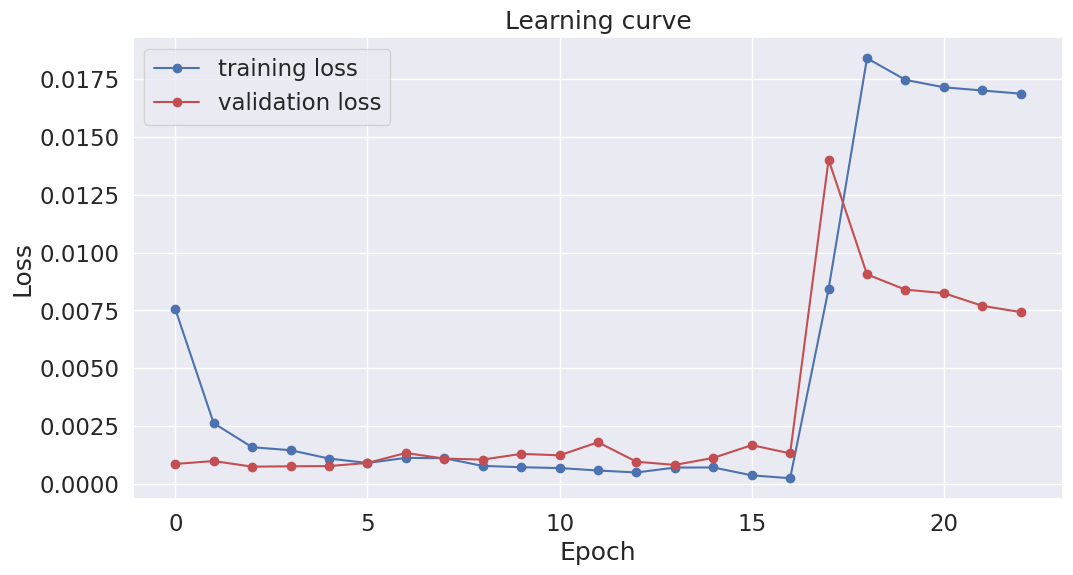

In [12]:
# Use plot styling from seaborn.
sns.set(style='darkgrid')

# Increase the plot size and font size.
sns.set(font_scale=1.5)
plt.rcParams["figure.figsize"] = (12,6)

# Plot the learning curve.
plt.plot(results["loss_values"], 'b-o', label="training loss")
plt.plot(results["development_loss_values"], 'r-o', label="validation loss")

# Label the plot.
plt.title("Learning curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

## **Eval model**

In [ ]:
token_distance_bins = {0: (0, 0), 1: (1, 2), 2: (3, 5), 3: (6, 10), 4: (11, 20), 5: (21, 40), 6: (41, 80), 7: (81, 160), 8: (161, float("inf"))}
negative_difficulty_by_bin = {0: "hard", 1: "hard", 2: "hard", 3: "hard", 4: "medium", 5: "medium", 6: "easy", 7: "easy", 8: "easy"}

print("1.1. Creating NER data // Test data")
dict_data_test = read_txt_list(ctx.paths.data_input / "CT-EBM-SP-v3/test")
# dict_data_test = read_txt_list(ctx.paths.data_input / "CT-EBM-SP-v2/test")
df_data_test = pd.DataFrame(list(dict_data_test.items()), columns=["archivo_origen", "Text"])

dict_ann_test = read_ann_list(ctx.paths.data_input / "CT-EBM-SP-v3/test")
# dict_ann_test = read_ann_list(ctx.paths.data_input / "CT-EBM-SP-v2/test")
df_ann_test = pd.DataFrame([{"archivo_origen": file_name, **ann_data}for file_name, ann_data in dict_ann_test.items()])
# df_ann = None

data_prepared_test, all_relation_labels_test, file_names_test, preparation_warnings_test, tokenizer_re = prepare_data_SYNC(data=df_data_test, data_ann=df_ann_test, entity_label_1="DISO", entity_label_2="LIVB", tokenizer=tokenizer_ner, w=2, v=1, 
                                                                                                         token_distance_bins=token_distance_bins, negative_difficulty_by_bin=negative_difficulty_by_bin, print_warnings=False, return_tokenizer=True)

all_relation_labels_test = remap_re_relation_labels(all_relation_labels_test, label2id={'O': 0, 'Experiences': 1}, id2label={0: 'O', 1: 'Experiences'}, outside_label="O", data_prepared=data_prepared_test)

model_ner.resize_token_embeddings(len(tokenizer_re))

1.1. Creating NER data // Test data


Preparing data for RE prediction: Entity pairs and marked contexts:   0%|          | 0/240 [00:00<?, ?text/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (833 > 512). Running this sequence through the model will result in indexing errors
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Embedding(250010, 1024, padding_idx=1)

In [7]:
aux = {}
for i in all_relation_labels_test:
    for j in i:
        if j not in aux:
            aux[j] = 0
        aux[j] += 1
aux

{'O': 17787, 'Experiences': 1178}

In [9]:
id2label

{0: 'O', 1: 'Experiences'}

In [8]:
id2label = read_json_single(ctx.paths.docs_dir / "RETraining/DISO_LIVB/id2label_diso_livb_reclassifier.json")
label2id = read_json_single(ctx.paths.docs_dir / "RETraining/DISO_LIVB/label2id_diso_livb_reclassifier.json")
id2label = {int(k): v for k, v in id2label.items()}
label2id = {v: int(k)  for k, v in id2label.items()}
dataset_full_test, data_loader_full_test, _, _ = construct_loader_re_SYNC(data_prepared_test, all_relation_labels_test, 
                                                                        file_names=file_names_test, label2id=label2id, id2label=id2label, seed=SEED, batch_size=16)

modelo_re = initialize_re_model(ctx, model_ner, len(id2label), len(token_distance_bins), "RETraining/DISO_LIVB/diso_livb_reclassifier_checkpoint.pt")

In [ ]:
results = run_re_classifier_SYNC(modelo_re, data_loader=data_loader_full_test, device=ctx.device, id2label=id2label, train=False)

RE / Inference:   0%|          | 0/1186 [00:00<?, ?batch/s]


Classification report:
              precision    recall  f1-score   support

 Experiences     0.9202    0.9694    0.9442      1178
           O     0.9980    0.9944    0.9962     17787

    accuracy                         0.9929     18965
   macro avg     0.9591    0.9819    0.9702     18965
weighted avg     0.9931    0.9929    0.9930     18965

